# Medical Images Project
---


## Objective 1: DICOM loading and visualization section

**a) Download the sample RadCTTACEomics DDDD (click here), where DDDD is the sample associated to you (see assignment in Aula Digital).**  

RadCTTACEomics_1447
  
- **Reference image**: 11_AP_Ax5.00mm
- **Input image**: 31_EQP_Ax5.00mm


In [1]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import matplotlib.animation as animation
from scipy.ndimage import gaussian_filter
from scipy import ndimage
from scipy.ndimage import label, binary_fill_holes
from skimage import measure, morphology, draw

In [2]:
print('Pydicom version: {}'.format(pydicom.__version__))
print('NumPy version: {}'.format(np.__version__))

Pydicom version: 2.3.1
NumPy version: 1.26.4


In [3]:
#Constants
path_reference='1447/11_AP_Ax5.00mm/'
path_input='1447/31_EQP_Ax5.00mm/'
path_roi_liver='1447/11_AP_Ax5.00mm_ManualROI_Liver.dcm'
path_roi_tumor='1447/11_AP_Ax5.00mm_ManualROI_Tumor.dcm'
# Arrays
file_gt_liver='gt_liver_mask.npy'
file_gt_tumor='gt_tumor_mask.npy'
file_ref_img='windowed_ct_images.npy'
file_aspect_ratio='ratio.npy'
#ratio
path_array_folder='task2_data'
os.makedirs(path_array_folder, exist_ok=True)

**b) Visualize it with the help of a third party DICOM visualizer (3D-Slicer is recommended).**   
To help use with the visualization we follow the advices from:
3rd party visualization: https://spujol.github.io/SlicerDICOMTutorial/3DSlicer_DICOMTutorial_SoniaPujol.pdf


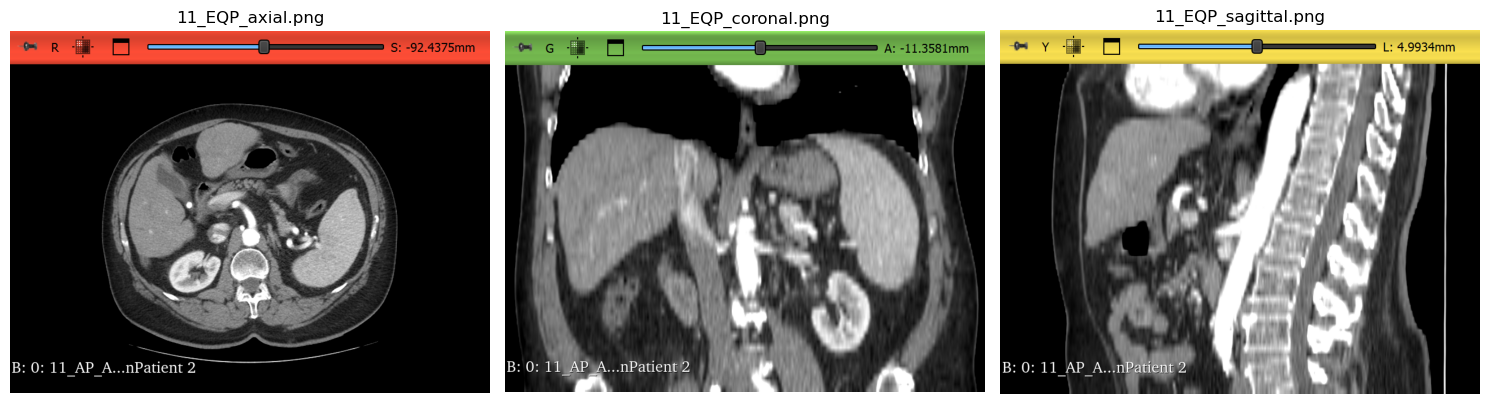

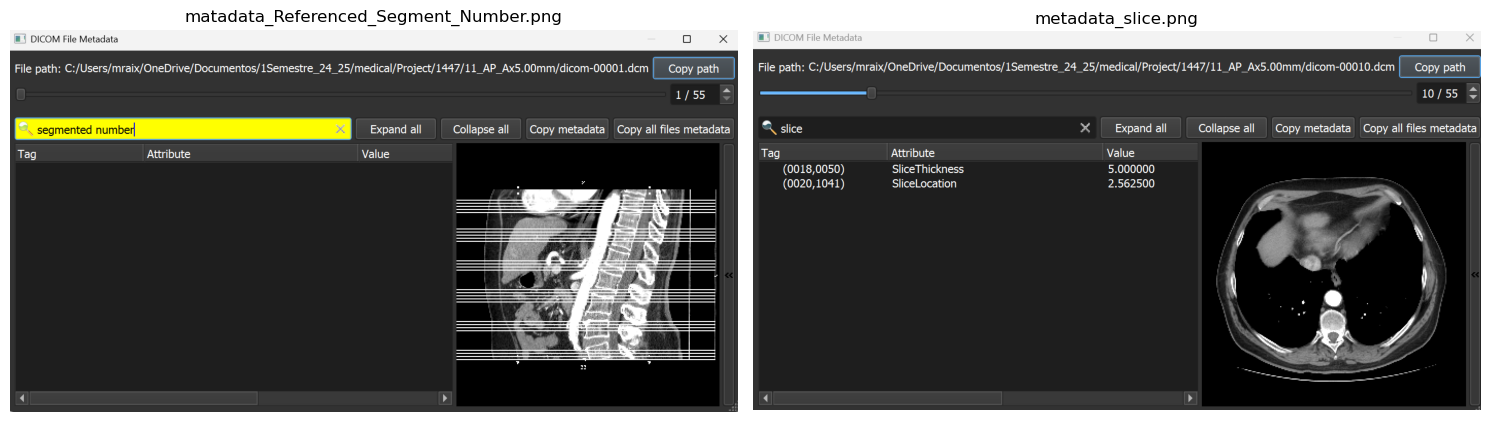

<Figure size 1500x500 with 0 Axes>

In [4]:
folder_path = '3d_slicer_photos/'
image_paths = list(Path(folder_path).glob('*.png'))  

group_pattern = [3, 2, 2]
groups = []
start_idx = 0

for count in group_pattern:
    end_idx = start_idx + count
    groups.append(image_paths[start_idx:end_idx])
    start_idx = end_idx

for group in groups:
    plt.figure(figsize=(15, 5))
    
    for idx, img_path in enumerate(group, 1):
        img = Image.open(img_path)
        
        plt.subplot(1, len(group), idx)
        plt.imshow(img)
        plt.axis('off')
        plt.title(img_path.name)
    
    plt.tight_layout()
    plt.show()


The visualisation is presented using 3D Slicer software. Python displays and processes images based on these disparate images captured on different image planes. A thorough review of the metadata pertaining to the reference image has been conducted for a selection of headers. This investigation was undertaken to ascertain the correlation between the various images, their relationship to one another, and the information that could be obtained. It is also checked the data's physical dimensions of the image data, as it is missing space between slices.

**c) Load the reference CT image (pydicom) and the associated segmentations (highdicom)**  
Rearrange the image and segmentation ‘pixel array’ given by PyDicom based on the headers. Some relevant headers include:  
- ‘Acquisition Number’.
- ‘Slice Index’.
- ‘Per-frame Functional Groups Sequence’ -> ‘Image Position Patient’.
- ‘Segment Identification Sequence’ -> ‘Referenced Segment Number’
---


To order the attributes consistently while considering one axis from the 3D position, follow these steps:

- Acquisition Number: Start by sorting images based on the acquisition number. This ensures that images from different scans (e.g., pre-contrast vs. post-contrast) are grouped separately. A smaller acquisition number indicates an earlier scan, so it should come first.

- Slice Index: Within each acquisition group, sort the images by their slice index. This arranges the slices in the correct sequential order for reconstructing the 3D volume.

- Image Position Patient (Specific Axis): If there is a tie in the slice index, sort the images based on one specific axis from the 3D position (e.g., the z-axis for axial slices). Consistently using one axis ensures proper alignment of slices in 3D space along that dimension.

- Referenced Segment Number: Finally, if all previous attributes are identical, sort by the referenced segment number to distinguish between different anatomical regions or structures within the image.

Headers study: This approach ensures consistency by focusing on a single axis for spatial alignment while maintaining a hierarchical ordering structure.
Headers of the reference image and of the segmented image of the liver have been manually reviewed. In the first of the 4 data requested, only the first 3 can be obtained. And in the case of the segmented image the position of the patient and the Referenced Segment Number.

example=pydicom.dcmread('../1447/11_AP_Ax5.00mm/dicom-00001.dcm')  
example_image = example.pixel_array

In [5]:
def load_dicom_files(directory):
    files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.dcm')]
    return [pydicom.dcmread(f) for f in files]

def extract_read_headers(dcm_files):
    headers = []
    for dcm_file in dcm_files:
        acquisition_number = dcm_file.get("AcquisitionNumber", None)
        slice_index = dcm_file.InstanceNumber
        img_position_patient = dcm_file.ImagePositionPatient if "ImagePositionPatient" in dcm_file else None
        img_orientation_patient=dcm_file.ImageOrientationPatient
        slice_location=dcm_file.SliceLocation
        headers.append({
            'file': dcm_file,
            'acquisition_number': acquisition_number,
            'slice_index': slice_index,
            'image_position_patient': img_position_patient,
            'img_orientation_patient':img_orientation_patient
        })
    return headers
    
def check_is_single_adquisition(headers):
    unique_acquisition_numbers = set()
    for header in headers:
        unique_acquisition_numbers.add(header['acquisition_number'])
    if len(unique_acquisition_numbers)==1:   
        print(f'The slices of the CT image contain only a single acquisition')
    else:
        print(f'The slices of the CT image contain more than one acquisition')
        
def rearrange_img_segmentation_by_headers(headers):
    # Sort headers based on the relevant attributes
    sorted_headers = sorted(headers, key=lambda x: (
        x['acquisition_number'] if x['acquisition_number'] is not None else 0,
        x['slice_index'] if x['slice_index'] is not None else 0,
        x['image_position_patient'][2] if x['image_position_patient'] is not None else 0,  # Sort by Z-axis
    ))

    return sorted_headers
def extract_pixel_arrays(sorted_headers):
    return np.stack([header['file'].pixel_array for header in sorted_headers])

def visualize_sorted_slices(sorted_headers, num_slices=5):
    fig, axes = plt.subplots(1, num_slices, figsize=(15, 5))
    for i in range(num_slices):
        axes[i].imshow(sorted_headers[i]['file'].pixel_array, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'Slice {i+1}')
    plt.show()
    
def save_sorted_images(sorted_headers, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for i, header in enumerate(sorted_headers):
        output_path = os.path.join(output_folder, f'sorted_image_{i}.dcm')
        header['file'].save_as(output_path)

def show_ordered_headers(sorted_headers):
    for i, header in enumerate(sorted_headers):
        print(f'Header {i+1}:')
        print(f'  Acquisition Number: {header["acquisition_number"]}')
        print(f'  Slice Index: {header["slice_index"]}')
        print(f'  Image Position Patient: {header["image_position_patient"]}')
        print(f'  Image Orientation Patient: {header["img_orientation_patient"]}')
    print(f'  Array Shape from reference image: {pixel_arrays.shape}')


In [6]:
dcm_files = load_dicom_files(path_reference)
headers = extract_read_headers(dcm_files)
check_is_single_adquisition(headers)
sorted_headers = rearrange_img_segmentation_by_headers(headers)
pixel_arrays = extract_pixel_arrays(sorted_headers)
show_ordered_headers(sorted_headers)

The slices of the CT image contain only a single acquisition
Header 1:
  Acquisition Number: 1
  Slice Index: 1
  Image Position Patient: [5.797, -187.399, 115.75]
  Image Orientation Patient: [0.000000, 1.000000, 0.000000, 0.000000, 0.000000, -1.000000]
Header 2:
  Acquisition Number: 1
  Slice Index: 2
  Image Position Patient: [-200.202, -194.642, 42.562]
  Image Orientation Patient: [1.000000, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000]
Header 3:
  Acquisition Number: 1
  Slice Index: 3
  Image Position Patient: [-200.202, -194.642, 37.562]
  Image Orientation Patient: [1.000000, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000]
Header 4:
  Acquisition Number: 1
  Slice Index: 4
  Image Position Patient: [-200.202, -194.642, 32.562]
  Image Orientation Patient: [1.000000, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000]
Header 5:
  Acquisition Number: 1
  Slice Index: 5
  Image Position Patient: [-200.202, -194.642, 27.562]
  Image Orientation Patient: [1.000000, 0.000000, 0

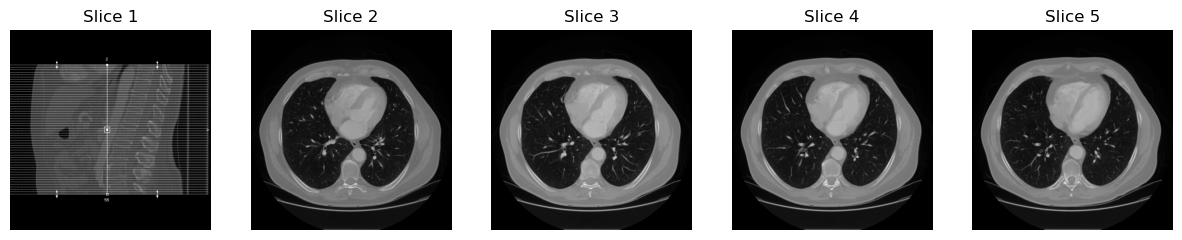

In [7]:
visualize_sorted_slices(sorted_headers)

As you can see we have 55 slices of the reference image, and its height and width is 512x512. We can also see how the first slice is the most different from the others in both orientation, patient position, and plane. 

---
Interesting data for next objectives.  
  
Orientation:  
- The first three numbers are the direction of the image rows.
- The next three numbers are the direction of the image columns.
- Both are given in the patient coordinate system: X (Right to Left), Y (Anterior to Posterior), Z (Inferior to Superior)

Data Analysis:

[0.000000, 1.000000, 0.000000, 0.000000, 0.000000, -1.000000]  
- Row direction: (0, 1, 0) → Along the Y axis (Anterior to Posterior)
- Column direction: (0, 0, -1) → Along the negative Z axis (Superior to Inferior)
- The image rows go from anterior to posterior.
- The image columns go from superior to inferior.
- The image plane is perpendicular to the X axis (Right to Left).
- This is a sagittal plane.

[1.000000, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000]
- Row direction: (1, 0, 0) → Along the x axis left to right
- Column direction: (0, 1, 0) → Along the Y axis (Anterior to Posterior)
- The image rows go from right to left.
- The image columns go from anterior to posterior.
- The image plane is perpendicular to the Z axis (Inferior to Superior).
  
This is an axial plane (top-down slices).

If there was a coronal, they would have the same row direction as in the axial, however the column direction: (0, 0, 1) - inferior to superior (patient’s Z-axis)  

---

In order to perform image enhancement, the window center and window width must be obtained. It is imperative to modify the image while preserving its values, as it is a medical image and those values correspond to a specific tissue. Using the window center and window width it maintains the physical relationship between HU values and tissue.

In [8]:
def get_windowing(dcm):
    try:
        window_center = float(dcm.WindowCenter)
        window_width = float(dcm.WindowWidth)
        print(f'window_center: {window_center}', f'window_width: {window_width}')
        return window_center, window_width
    except AttributeError:
        # Estimate windowing if not present WindowCenter, and WindowWidth
        pixels = dcm.pixel_array
        max_value = np.max(pixels)
        min_value = np.min(pixels)
        window_center = (max_value + min_value) / 2
        window_width = max_value - min_value
        return window_center, window_width

def apply_windowing(pixel_array, window_center, window_width):
    lower_bound = window_center - window_width 
    upper_bound = window_center + window_width 
    windowed_array = np.clip(pixel_array, lower_bound, upper_bound)
    return windowed_array

In [9]:
window_center, window_width = get_windowing(dcm_files[1])
windowed_ct_images = np.array([apply_windowing(img, window_center, window_width) for img  in pixel_arrays])

window_center: 40.0 window_width: 400.0


As the first image has artifacts from the machine, it is needed to remove those artifacts. Prior to that we will do windowing, and then apply FFT-based removal. Then the dynamic range (min/max values) of the image can change, often reducing the contrast between the torso and the background. Better in this order, or in the other way around the FFT may introduce negative values or flatten intensity differences, and applying windowing after the image will not show correctly on the image.  

The process of normalisation and denormalisation is employed in order to ensure the preservation of the minimum and maximum values of the original image. Furthermore, the mask applied in the frequency domain is designed to eliminate grid-like artefacts. The application of the Gaussian filter with sigma 0.3 as it is enough for the objective according to [HU article](https://taylorandfrancis.com/knowledge/Engineering_and_technology/Biomedical_engineering/HU/) to the mask has been demonstrated to introduce a degree of smoothing, which may result in a slight blurring of the image. However, it is asserted that this process should not lead to a significant alteration of the Hounsfield values.

In [10]:
def normalize_img(img):
    # Normalize to [0, 1]
    img = img.astype(np.float32)
    return (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)

def denormalize_img(img_norm, original_min, original_max):
    # Map normalized [0,1] image back to original range
    return img_norm * (original_max - original_min) + original_min

def apply_fft(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    return 20 * np.log(np.abs(fshift) + 1), fshift

def create_mask(img, band_size=5, center_size=15):
    rows, cols = img.shape
    crow, ccol = rows // 2 , cols // 2
    mask = np.ones((rows, cols), np.float32)
    # Block grid frequency lines (horizontal and vertical)
    mask[crow-band_size:crow+band_size, :] = 0
    mask[:, ccol-band_size:ccol+band_size] = 0
    # Allow a center area (low frequencies)
    mask[crow-center_size:crow+center_size, ccol-center_size:ccol+center_size] = 1
    # Smooth with gaussian
    mask = gaussian_filter(mask, sigma=0.3)
    return mask

def apply_mask_inv_fft(fshift, mask):
    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.real(img_back)  # Use real part, as input is real
    return img_back

def extract_machine_grid(img, show=False):
    # Save original min/max for later
    orig_min, orig_max = np.min(img), np.max(img)
    img_norm = normalize_img(img)
    # Apply FFT
    magnitude_spectrum, fshift = apply_fft(img_norm)
    # Show spectrum
    if show:
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1), plt.imshow(img, cmap='gray'), plt.title('Original Image')
        plt.subplot(1,2,2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title('FFT Spectrum')
        plt.show()
    # Mask and inverse FFT
    mask = create_mask(img)
    img_back = apply_mask_inv_fft(fshift, mask)
    # Re-normalize to [0, 1]
    img_back_norm = normalize_img(img_back)
    # Scale back to original range (or HU)
    img_back_scaled = denormalize_img(img_back_norm, orig_min, orig_max)
    if show:
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1), plt.imshow(img, cmap='gray'), plt.title('Original')
        plt.subplot(1,2,2), plt.imshow(img_back_scaled, cmap='gray'), plt.title('Grid Removed')
        plt.show()
    return magnitude_spectrum, mask, img_back_scaled, fshift

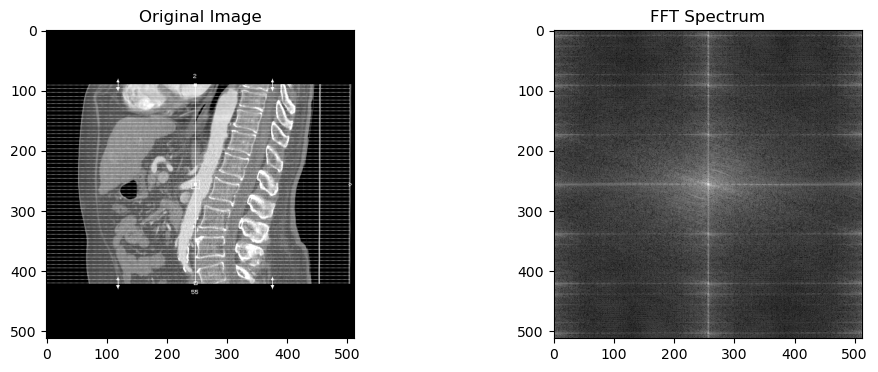

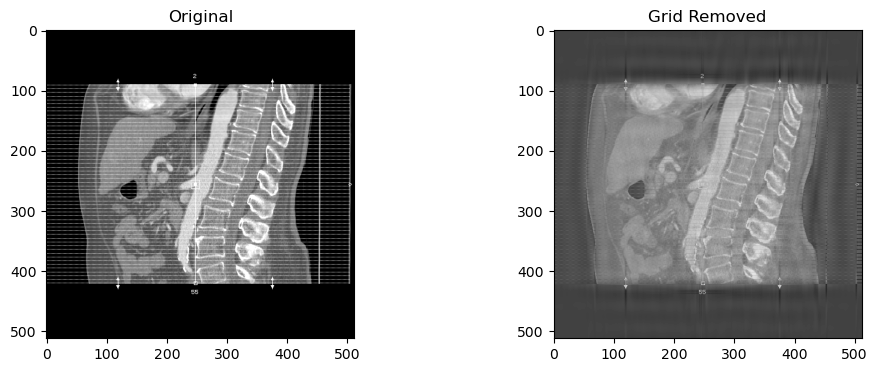

In [11]:
img = windowed_ct_images[0].astype(float)
magnitude_spectrum,mask,img_back,fshift=extract_machine_grid(img,show=True)
windowed_ct_images[0]=img_back

**Segmented images section**

---
Liver and tumor ROI reading the headers obtaing Z position from the patient and Referenced Segment Number. It will first be used to order by the patient's Z-position, then by the Referenced Segment Number. This is the Z position, descending as in the reference image.

In [12]:
def read_order_seg_header(seg_file):
    seg_data = []
    shared = seg_file.SharedFunctionalGroupsSequence[0]
    img_orientation_patient = shared.PlaneOrientationSequence[0].ImageOrientationPatient
    slice_thickness = shared.PixelMeasuresSequence[0].SliceThickness
    pixel_spacing = shared.PixelMeasuresSequence[0].PixelSpacing
    for idx, frame in enumerate(seg_file.PerFrameFunctionalGroupsSequence):
        #position = float(frame.PlanePositionSequence[0].ImagePositionPatient[2])
        img_position_patient = frame.PlanePositionSequence[0].ImagePositionPatient
        referenced_segment_number = frame.SegmentIdentificationSequence[0].ReferencedSegmentNumber
        
        seg_data.append({
            'file': idx,
            'image_position_patient': img_position_patient,
            'referenced_segment_number': referenced_segment_number
        })
        seg_data=rearrange_img_segmentation_by_headers(seg_data)
    return seg_data
    
def rearrange_img_segmentation_by_headers(headers):
    sorted_headers = sorted(headers, key=lambda x: (
    -x['image_position_patient'][2] if x['image_position_patient'] is not None else 0,
    x['referenced_segment_number'] if x['referenced_segment_number'] is not None else 0))

    return sorted_headers
    
def order_pixel_data(seg_data, pixel_data):
    sorted_indices = [item['file'] for item in seg_data]
    sorted_pixel_data = pixel_data[sorted_indices, :, :]
    return sorted_pixel_data

def visualize_sorted_slices(sorted_pixel_arrays, num_slices=5):
    fig, axes = plt.subplots(1, num_slices, figsize=(15, 5))
    for i in range(num_slices):
        axes[i].imshow(sorted_pixel_arrays[i], cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'Slice {i+1}')
    plt.show()

def show_seg_header(sorted_headers):
    for i,item in enumerate(sorted_headers):
        print(f'Header {i+1}:')
        print(f'   Position Patient: {item["image_position_patient"]}')
        print(f'  Referenced Segment Number: {item["referenced_segment_number"]}')

In [13]:
liver_segmentation = pydicom.dcmread(path_roi_liver)
liver_image = liver_segmentation.pixel_array

In [14]:
seg_data=read_order_seg_header(liver_segmentation)
show_seg_header(seg_data)
sorted_pixel_data=order_pixel_data(seg_data,liver_image)
print(f'Array Shape from liver segmentation image: {liver_image.shape}')

Header 1:
   Position Patient: [-200.202, -194.642, 7.562]
  Referenced Segment Number: 1
Header 2:
   Position Patient: [-200.202, -194.642, 2.562]
  Referenced Segment Number: 1
Header 3:
   Position Patient: [-200.202, -194.642, -2.437]
  Referenced Segment Number: 1
Header 4:
   Position Patient: [-200.202, -194.642, -7.437]
  Referenced Segment Number: 1
Header 5:
   Position Patient: [-200.202, -194.642, -12.437]
  Referenced Segment Number: 1
Header 6:
   Position Patient: [-200.202, -194.642, -17.437]
  Referenced Segment Number: 1
Header 7:
   Position Patient: [-200.202, -194.642, -22.437]
  Referenced Segment Number: 1
Header 8:
   Position Patient: [-200.202, -194.642, -27.437]
  Referenced Segment Number: 1
Header 9:
   Position Patient: [-200.202, -194.642, -32.437]
  Referenced Segment Number: 1
Header 10:
   Position Patient: [-200.202, -194.642, -37.437]
  Referenced Segment Number: 1
Header 11:
   Position Patient: [-200.202, -194.642, -42.437]
  Referenced Segment Nu

In [15]:
tumor_segmentation = pydicom.dcmread(path_roi_tumor)
tumor_image = tumor_segmentation.pixel_array

In [16]:
seg_tumor_data=read_order_seg_header(tumor_segmentation)
show_seg_header(seg_tumor_data)
sorted_tumor_pixel_data=order_pixel_data(seg_tumor_data,tumor_image)
print(f'Array Shape from tumor segmentation image: {tumor_image.shape}')

Header 1:
   Position Patient: [-200.202, -194.642, -7.437]
  Referenced Segment Number: 1
Header 2:
   Position Patient: [-200.202, -194.642, -12.437]
  Referenced Segment Number: 1
Header 3:
   Position Patient: [-200.202, -194.642, -17.437]
  Referenced Segment Number: 1
Header 4:
   Position Patient: [-200.202, -194.642, -22.437]
  Referenced Segment Number: 1
Header 5:
   Position Patient: [-200.202, -194.642, -42.437]
  Referenced Segment Number: 1
Header 6:
   Position Patient: [-200.202, -194.642, -47.437]
  Referenced Segment Number: 1
Header 7:
   Position Patient: [-200.202, -194.642, -52.437]
  Referenced Segment Number: 1
Header 8:
   Position Patient: [-200.202, -194.642, -57.437]
  Referenced Segment Number: 1
Header 9:
   Position Patient: [-200.202, -194.642, -62.437]
  Referenced Segment Number: 1
Header 10:
   Position Patient: [-200.202, -194.642, -67.437]
  Referenced Segment Number: 1
Header 11:
   Position Patient: [-200.202, -194.642, -77.437]
  Referenced Segme

Referenced Segment Number, which is from the segmentation data, then we have to use path_roi_tumor and path_roi_liver.  

As we can see in both segmented images we do not have the same number of pixel arrays. In the reference image there are about 55, and in the liver segmentation there are 40, and in the tumor one there are 13, so it is not possible to make a simple reslice. As reference data we have the position of the patient, but in the reference image there are about 55 different Z positions, so they will not all coincide. 

---

Reslice the liver and tumor files to fit the reference image. It is imperative to consider the patient's position, in combination with the prior analysis of the headers. This is due to the fact that, despite the reduced number of slices in the ROI relative to the CT image, patient position variations are confined to the Z axis in both cases.

In [17]:
def extract_ordered_dcm_files(sorted_headers):
    return [header['file'] for header in sorted_headers]
def reorder_roi_match_file(sorted_headers,pixel_array,resliced_roi, dcm_seg):
    # Obtinning the slices, height and width from the reference pixel array
    shape = pixel_array.shape
    
    dcm_files=extract_ordered_dcm_files(sorted_headers)
    # Obtaining Z position from the patient
    ref_positions = [float(dcm.ImagePositionPatient[2]) for dcm in dcm_files]
    ref_pos_to_index = {z: idx for idx, z in enumerate(ref_positions)}
    # Initialization of the mask
    seg_mask = np.zeros(shape, dtype=dcm_seg.pixel_array.dtype)
    for frame_idx, frame in enumerate(dcm_seg.PerFrameFunctionalGroupsSequence):
        # Obtaining Z position from the patient from the mask
        mask_z = float(frame.PlanePositionSequence[0].ImagePositionPatient[2])
        # Find the corresponding table of contents in the original volume
        if mask_z in ref_pos_to_index:
            vol_idx = ref_pos_to_index[mask_z]
            # Insert the mask slice in the correct position.
            seg_mask[vol_idx] = resliced_roi[frame_idx]
        else:
            print(f'Warning: No match found for Z position={mask_z}')
    return seg_mask

In [18]:
liver_mask=reorder_roi_match_file(sorted_headers,pixel_arrays,liver_image,liver_segmentation)
print(f'Array Shape from liver resliced: {liver_mask.shape}')

Array Shape from liver resliced: (55, 512, 512)


In [19]:
tumor_mask=reorder_roi_match_file(sorted_headers,pixel_arrays,tumor_image,tumor_segmentation)
print(f'Array Shape from liver resliced: {tumor_mask.shape}')

Array Shape from liver resliced: (55, 512, 512)


In [20]:
out_path = os.path.join(path_array_folder, file_gt_liver)
np.save(out_path, liver_mask)
out_path = os.path.join(path_array_folder, file_gt_tumor)
np.save(out_path, tumor_mask)

Check if the reslice is correct, we use the 20th image where both ROIs are clearly shown. Both masks have the same shape as the reference image.

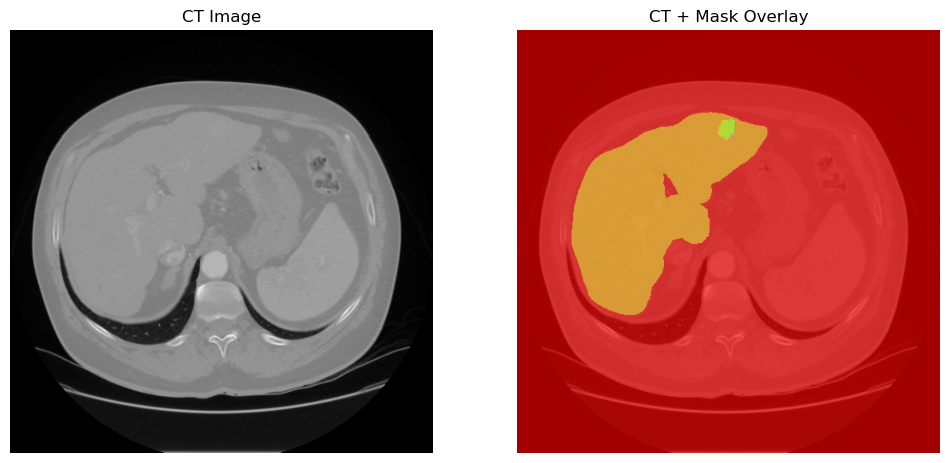

In [21]:
slice_idx =20
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('CT Image')
plt.imshow(pixel_arrays[slice_idx], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('CT + Mask Overlay')
plt.imshow(pixel_arrays[slice_idx], cmap='gray')
plt.imshow(tumor_mask[slice_idx], cmap='prism', alpha=0.4)  
plt.imshow(liver_mask[slice_idx], cmap='autumn', alpha=0.4)  # Mask in color, semi-transparent
plt.axis('off')
plt.show()


**d) Create an animation (e.g. gif file) with a rotating Maximum Intensity Projection on the
coronal-sagittal planes, visualizing the tumoral mask.**  

Before creating the Maximum Intensity Projection in GIF format, it is needed to obtain the correct aspect ratios and remove the noise.
Maintaining the correct aspect ratio in the different planes of a medical image is essential to avoid distortions, ensuring diagnostic accuracy.  

Since the headers do not contain the space between slices information, we must calculate this data. Then each CT slice includes an 'Image Position (Patient)' field, which gives the 3D coordinates (in mm) of the upper-left voxel of the image in the patient coordinate system. Obtaining the difference between the different two adjacent slices, this difference is calculate euclidean distance.



A review of the axial plans revealed a curved line moving behind the column in the sagittal plane as a vertical line. It is therefore necessary to remove this line when creating the GIF, this noise will be amplified and will manifest itself as visual artifacts, streaks or moving spots, making it difficult to interpret the actual structures and reducing the quality of the display.


Axial aspect ration 1.0
Sagittal aspect ration 6.213588372139264
Coronal aspect ration 6.213588372139264


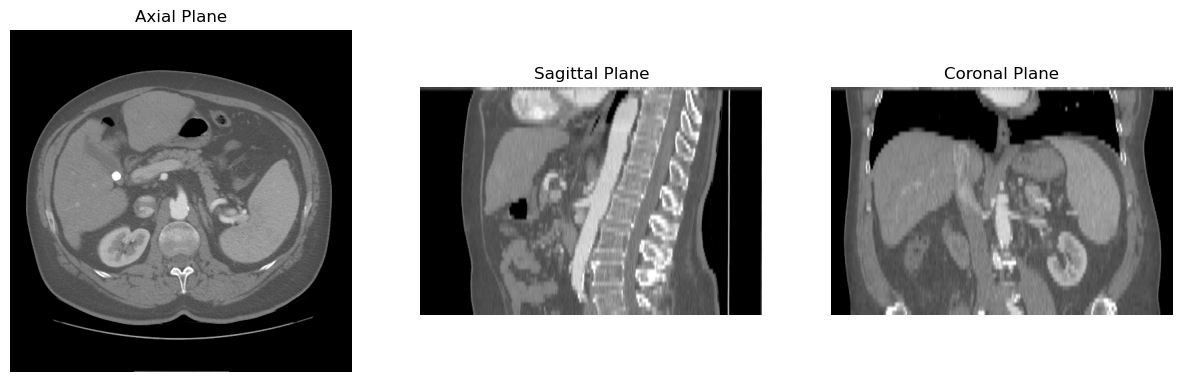

In [22]:
def get_image_position(ds):
    # Returns the Image Position (Patient) as a numpy array
    return np.array(ds.ImagePositionPatient, dtype=float)
   
def obtain_space_data(images):
    sample_img=images[0]
    
    pixel_spacing = sample_img.PixelSpacing  #is an array for the x and y 
    # Get positions
    space_between_slices=None
    positions=[]
    #Do not use first slice as is not in the same plane as the rest
    positions.append(get_image_position(images[1]))
    positions.append(get_image_position(images[2]))
    if len(positions) >= 2:
        space_between_slices = np.linalg.norm(positions[1] - positions[0])
   
    slice_thickness = sample_img.SliceThickness
    return pixel_spacing, space_between_slices, slice_thickness
 
def obtain_aspects_planes(images):
    pixel_spacing, space_between_slices, slice_thickness=obtain_space_data(images)

    axial_aspect_ratio = pixel_spacing[1] / pixel_spacing[0]
    sagittal_aspect_ratio = space_between_slices/pixel_spacing[0]
    coronal_aspect_ratio =  space_between_slices /pixel_spacing[1]
    
    print(f'Axial aspect ration {axial_aspect_ratio}')
    print(f'Sagittal aspect ration {sagittal_aspect_ratio}')
    print(f'Coronal aspect ration {coronal_aspect_ratio}')
    return axial_aspect_ratio,sagittal_aspect_ratio, coronal_aspect_ratio
    
def visualize_planes(ct_volume,axial_aspect_ratio, aspect_ratio_sagittal, aspect_ratio_coronal):
   
    # Obtaining planes based on the corresponding axis as ct_volume shape SlicesxHeightxWidth
    coronal_plane =ct_volume[:, ct_volume.shape[2] // 2, :] 
    sagittal_plane = ct_volume[:, :, ct_volume.shape[1] // 2]
    axial_plane = ct_volume[ct_volume.shape[0] // 2, :, :]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    # Visualize planes with aspect
    axes[0].imshow(axial_plane, cmap='gray', aspect=axial_aspect_ratio)
    axes[0].set_title('Axial Plane')
    axes[0].axis('off')
    
    axes[1].imshow(sagittal_plane, cmap='gray', aspect=aspect_ratio_sagittal)
    axes[1].set_title('Sagittal Plane')
    axes[1].axis('off')
    
    axes[2].imshow(coronal_plane, cmap='gray', aspect=aspect_ratio_coronal)
    axes[2].set_title('Coronal Plane')
    axes[2].axis('off')

    plt.show()
    
axial_aspect_ratio,aspect_ratio_sagittal, aspect_ratio_coronal=obtain_aspects_planes(dcm_files)
visualize_planes(windowed_ct_images,axial_aspect_ratio, aspect_ratio_sagittal, aspect_ratio_coronal)

In [23]:
ratio=[axial_aspect_ratio, aspect_ratio_sagittal, aspect_ratio_coronal]
array_path = os.path.join(path_array_folder, file_aspect_ratio)
np.save(array_path, ratio)

In [24]:

def remove_lower_horizontal_line_safe(image,threshold=0,lower_frac=0.119,min_line_length=20):
    '''
    Removes a horizontal line/curve from the lower part of a float64 image,
    Only if the detected object is a thin line (not a region with area).
    '''
    # Binarize image
    binary = image > threshold

    # Focus on lower part, lower_frac is fraction of image height to check at the bottom
    h = binary.shape[0]
    lower_start = int((1 - lower_frac) * h)
    lower_part = np.zeros_like(binary)
    lower_part[lower_start:] = binary[lower_start:]

    # Detect contours
    contours = measure.find_contours(lower_part, 0.5)
    line_mask = np.zeros_like(binary, dtype=bool)
    line_found = False
    for c in contours:
        # Check if has at least the minimum length for a contour to be considered a line
        if len(c) < min_line_length:
            continue
        # Fill the polygon/contour to get the area
        rr, cc = draw.polygon(c[:, 0], c[:, 1], binary.shape)
        # Only keep if the area is less than the threshold (i.e., a line, not a region)
        area = len(rr)
        if area > 0:
            line_mask[rr, cc] = True
            line_found = True
    # Thicken the line a little
    if line_found:
        line_mask = morphology.binary_dilation(line_mask, morphology.disk(2))

    # Remove line from image if it is a line
    cleaned_image = image.copy()
    if line_found and np.sum(line_mask) > 0:
        cleaned_image[line_mask] = image[0][0]
    return cleaned_image

ct_image=windowed_ct_images.copy()

for slice_idx in range(1,ct_image.shape[0]):
     ct_image[slice_idx] = remove_lower_horizontal_line_safe(ct_image[slice_idx])


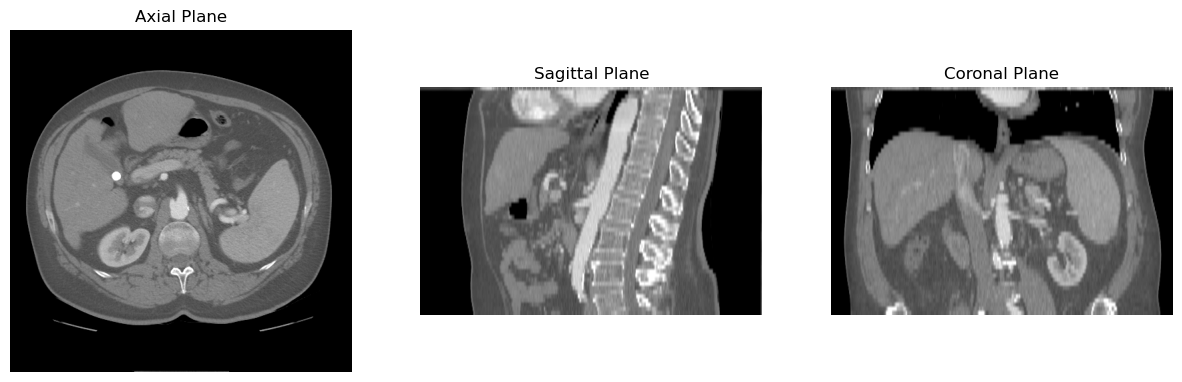

In [25]:
visualize_planes(ct_image,axial_aspect_ratio, aspect_ratio_sagittal, aspect_ratio_coronal)

In [26]:
out_path = os.path.join(path_array_folder, file_ref_img)
np.save(out_path, ct_image)

**GIF creation**  
Do the alpha blending of both masks with the windowed images, and then create projections save them, and create the GIF. In the mask treatment, it is only used alpha blending without using painter's algorithm as the 1st is enough, and the painter's algorithm is predicated on a fixed depth order. Consequently, during rotation of the scene, objects previously situated in the background (e.g. the 'nodule') may move to the front, thereby causing the algorithm to erroneously paint over overlaps. This phenomenon can result in the concealment of crucial components or their misplacement, particularly in scenes characterised by intricate geometry or intersections.  

For the liver is use the red, and the green is for the tumor.
Use 250 milliseconds to have a middle speed spin to correctly view the mask. The GIF that we created is both the tumor mask and the liver mask, as the latter stands out in the context of where the tumor is.

In [27]:
def create_solid_overlay_rotation_gif(volume, mask1, mask2, n_frames=36,  interval=100, output_path='animation_gif', alpha=0.5):

    # Ensure output path exists
    os.makedirs(output_path, exist_ok=True)
    fig, ax = plt.subplots(figsize=(7, 7))
    ims = []
    angle_step = 360 / n_frames

    for i in range(n_frames):
        angle = i * angle_step
        #counterclockwise rotation
        #rotation is performed in the plane formed by the second and third dimensions
        #Stablish for reference image bilinear interpolation (order=1)  for continuous data to achieve smooth interpolation
        vol_rot = ndimage.rotate(volume, angle=angle, axes=(1,2), reshape=False, order=1)
        # Masks use Nearest-neighbor (order=0) preserve discrete label values
        mask1_rot = ndimage.rotate(mask1, angle=angle, axes=(1,2), reshape=False, order=0)
        mask2_rot = ndimage.rotate(mask2, angle=angle, axes=(1,2), reshape=False, order=0)
        # Obtain MIPs
        mip_vol = np.max(vol_rot, axis=1)
        mip1 = np.max(mask1_rot, axis=1) > 0
        mip2 = np.max(mask2_rot, axis=1) > 0
        # Prepare regions for Alpha blending
        overlap = mip1 & mip2
        only1 = mip1 & ~mip2
        only2 = mip2 & ~mip1

        # Normalize background
        mip_norm = (mip_vol - np.min(mip_vol)) / (np.ptp(mip_vol) + 1e-8)
        rgb = plt.get_cmap('bone')(mip_norm)[..., :3]

        # Define colors
        color1 = np.array([1,0,0])   # Red
        color2 = np.array([1,0,1]) # Magenta
        color_overlap = np.array([0,1,0])   # Green

        # Blend overlays using alpha blending to have transparency
        # Integrate the same color blending logic across all RGB channels.
        #If a pixel belongs to more than one mask, 
        #the last applied mask in the sequence will determine the final color at that pixel.
        #Let the pixel that does not belong to any mask unchange.
        # Only1
        for c in range(3):
            rgb[...,c] = np.where(
                only1,
                (1 - alpha) * rgb[...,c] + alpha * color1[c],
                rgb[...,c]
            )
        # Only2
        for c in range(3):
            rgb[...,c] = np.where(
                only2,
                (1 - alpha) * rgb[...,c] + alpha * color2[c],
                rgb[...,c]
            )
        # Overlap
        for c in range(3):
            rgb[...,c] = np.where(
                overlap,
                (1 - alpha) * rgb[...,c] + alpha * color_overlap[c],
                rgb[...,c]
            )

        # For animation 
        # Avoiding out of range colors.
        img = ax.imshow(rgb, animated=True, aspect=aspect_ratio_coronal, interpolation='bilinear')
        title = ax.text(
            0.5, 1.01, f'Overlay - Angle {int(angle)}°', color='black',
            ha='center', va='bottom', transform=ax.transAxes, fontsize=10
        )
        ims.append([img, title])

        # A separate figure to avoid interfering with the animation
        # Create the projections
        fig2, ax2 = plt.subplots(figsize=(7, 7))
        ax2.imshow(rgb, aspect=aspect_ratio_coronal)
        ax2.axis('off')
        ax2.set_title(f'Angle {int(angle)}°', fontsize=10)
        plt.tight_layout()
        png_path = os.path.join(output_path, f'projection_{i:03d}.png')
        plt.savefig(png_path, bbox_inches='tight', pad_inches=0)
        plt.close(fig2)

    ax.axis('off')
    plt.tight_layout()
    ani = animation.ArtistAnimation(fig, ims, interval=interval, blit=True)
    gif_path = os.path.join(output_path, 'Animation.gif')
    ani.save(gif_path, writer='pillow')
    plt.close(fig)
    return ani 
ani=create_solid_overlay_rotation_gif(ct_image, liver_mask, tumor_mask,n_frames=36, interval=250)